# **AU2544013 - Hardi Hiteshbhai Makwana**
# **AU2544030 - Krisha Doshi**


In [1]:
import os
import pandas as pd
import numpy as np
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import eli5
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
from sklearn.neighbors import NearestNeighbors
from IPython.display import display, Markdown
import matplotlib.gridspec as gridspec
from sklearn.inspection import PartialDependenceDisplay

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, auc,
    confusion_matrix, classification_report,
    brier_score_loss, matthews_corrcoef, log_loss
)
from scipy.stats import ks_2samp

shap.initjs()  # Initialise SHAP's JavaScript for interactive plots
print('All libraries imported successfully.')

All libraries imported successfully.


## **2. Loading Data and Trained Models**


In [2]:
print('--- Loading Processed Data ---')
data_dir = 'MSME_Processed_Data'

X_train = pd.read_csv(os.path.join(data_dir, 'X_train_ready.csv'))
y_train = pd.read_csv(os.path.join(data_dir, 'y_train_ready.csv')).squeeze()
X_val   = pd.read_csv(os.path.join(data_dir, 'X_val_ready.csv'))
y_val   = pd.read_csv(os.path.join(data_dir, 'y_val_ready.csv')).squeeze()
X_test  = pd.read_csv(os.path.join(data_dir, 'X_test_ready.csv'))
y_test  = pd.read_csv(os.path.join(data_dir, 'y_test_ready.csv')).squeeze()

print(f'Train  : {X_train.shape}  |  Val : {X_val.shape}  |  Test : {X_test.shape}')
print(f'Features : {X_test.shape[1]}')

--- Loading Processed Data ---
Train  : (2242, 174)  |  Val : (256, 174)  |  Test : (257, 174)
Features : 174


In [3]:
print('--- Loading Saved Models ---')
save_dir = 'saved_models'

model_files = {
    'Logistic_Regression'    : 'Best_MSME_Model_Logistic_Regression.pkl',
    'Balanced_Random_Forest' : 'Best_MSME_Model_Balanced_Random_Forest.pkl',
    'XGBoost'                : 'Best_MSME_Model_XGBoost.pkl',
    'CatBoost'               : 'Best_MSME_Model_CatBoost.pkl'
}

models = {}
for name, fname in model_files.items():
    path = os.path.join(save_dir, fname)
    if os.path.exists(path):
        models[name] = joblib.load(path)
        print(f'  Loaded : {name}')
    else:
        print(f'  NOT FOUND (skipped) : {path}')

# Compute test probabilities for all loaded models
probs = {name: m.predict_proba(X_test)[:, 1] for name, m in models.items()}
aucs  = {name: roc_auc_score(y_test, p) for name, p in probs.items()}

# Dynamically pick the best model
best_name  = max(aucs, key=aucs.get)
best_model = models[best_name]
best_probs = probs[best_name]
best_auc   = aucs[best_name]

print(f'\nBest Model : {best_name}  (Test ROC-AUC = {best_auc:.4f})')

--- Loading Saved Models ---
  NOT FOUND (skipped) : saved_models/Best_MSME_Model_Logistic_Regression.pkl
  NOT FOUND (skipped) : saved_models/Best_MSME_Model_Balanced_Random_Forest.pkl
  NOT FOUND (skipped) : saved_models/Best_MSME_Model_XGBoost.pkl
  Loaded : CatBoost

Best Model : CatBoost  (Test ROC-AUC = 0.7594)


## **3. Implementing SHAP Values**


In [4]:
print(f'--- Computing SHAP Values for {best_name} ---')

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# For multi-output models (some CatBoost versions), extract class-1 SHAP values
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Expected (baseline) value — the model's average output over training data
exp_val = explainer.expected_value
if isinstance(exp_val, (list, np.ndarray)):
    exp_val = float(exp_val[0])

print(f'SHAP values shape  : {shap_values.shape}  ({X_test.shape[0]} companies x {X_test.shape[1]} features)')
print(f'Baseline log-odds  : {exp_val:.4f}  (model average prediction before any features are seen)')

--- Computing SHAP Values for CatBoost ---
SHAP values shape  : (257, 174)  (257 companies x 174 features)
Baseline log-odds  : -0.0044  (model average prediction before any features are seen)


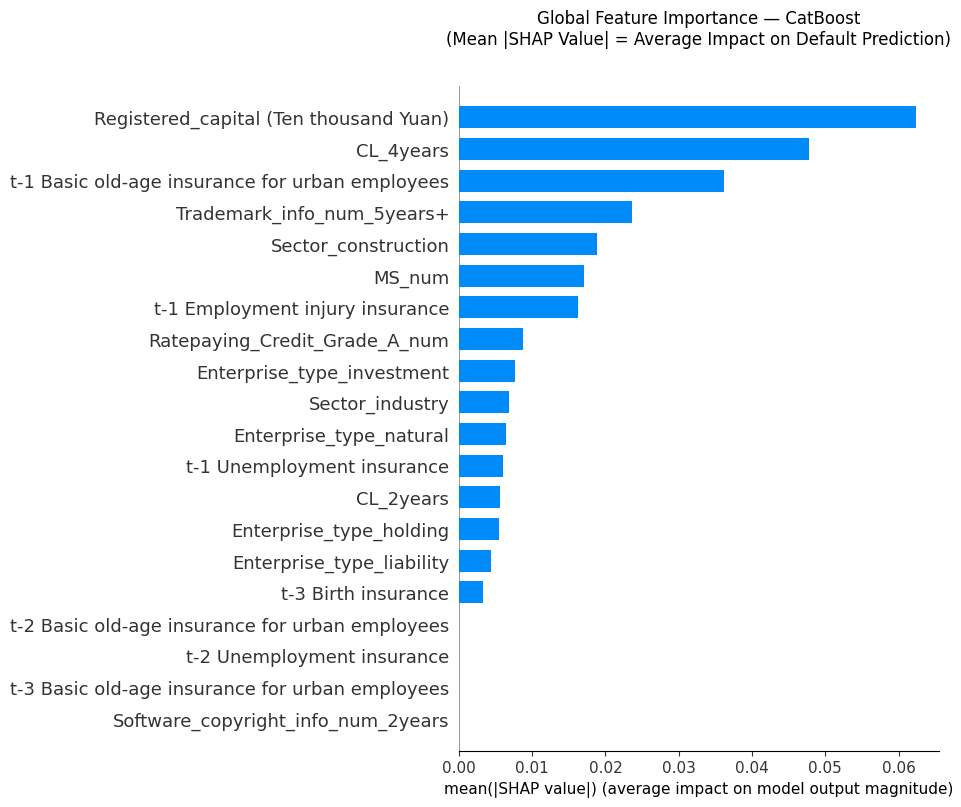

### 📊 Text Interpretation — Global SHAP Feature Importance (CatBoost)

**What does this chart show?**
The bar chart ranks every feature by its *mean absolute SHAP value* — the average magnitude by which that feature shifts the model's prediction (in log-odds space) across all test companies. A longer bar means the feature consistently moves predictions further from the baseline, making it more influential.

**Baseline (expected) prediction:** `-0.0044` (log-odds). This is the model's output if it had seen *no* feature values at all.

**Top 5 most influential features:**
1. `Registered_capital (Ten thousand Yuan)` — mean |SHAP| = **0.0624**
2. `CL_4years` — mean |SHAP| = **0.0478**
3. `t-1 Basic old-age insurance for urban employees` — mean |SHAP| = **0.0362**
4. `Trademark_info_num_5years+` — mean |SHAP| = **0.0237**
5. `Sector_construction` — mean |SHAP| = **0.0188**

**5 least influential features (bottom of chart):**
1. `t-3 Unemployment insurance` — mean |SHAP| = **0.0000**
2. `t-1 Basic medical insurance for employees` — mean |SHAP| = **0.0000**
3. `t-2 Basic medical insurance for employees` — mean |SHAP| = **0.0000**
4. `t-3 Basic medical insurance for employees` — mean |SHAP| = **0.0000**
5. `Province_Zhejiang` — mean |SHAP| = **0.0000**

**Credit Risk Insight:**
The top feature — `Registered_capital (Ten thousand Yuan)` — alone contributes an average shift of `0.0624` log-odds per company. Features with near-zero SHAP values may be candidates for removal in future model iterations to reduce complexity without sacrificing accuracy.

In [5]:
# 1. Increase height slightly but not to 20 (which causes scaling issues)
plt.figure(figsize=(10, 14)) 

# 2. Generate the plot
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=20)

# 3. Add Title with 'pad' to ensure it doesn't touch the top edge
plt.title(f'Global Feature Importance — {best_name}\n(Mean |SHAP Value| = Average Impact on Default Prediction)', 
          fontsize=12, pad=30)

# 4. MANUALLY set the margins (This is more reliable than tight_layout)
# left=0.3 gives room for long feature names
# bottom=0.15 gives room for the X-axis label
# top=0.85 gives room for the Title
plt.subplots_adjust(left=0.3, right=0.9, top=0.85, bottom=0.15)

# 5. Explicitly set the X-axis label just in case
plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)", fontsize=11)

# 6. Save with 'tight' padding
plt.savefig('shap_global_importance_final.png', dpi=150, bbox_inches='tight')
plt.show()
# ----- Text Explanation -----
mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X_test.columns)
mean_shap = mean_shap.sort_values(ascending=False)

top5    = mean_shap.head(5)
bottom5 = mean_shap.tail(5)

lines = [
    f'### 📊 Text Interpretation — Global SHAP Feature Importance ({best_name})',
    '',
    '**What does this chart show?**',
    'The bar chart ranks every feature by its *mean absolute SHAP value* — the average magnitude by which '
    'that feature shifts the model\'s prediction (in log-odds space) across all test companies. '
    'A longer bar means the feature consistently moves predictions further from the baseline, making it more influential.',
    '',
    f'**Baseline (expected) prediction:** `{exp_val:.4f}` (log-odds). This is the model\'s output if it had seen *no* feature values at all.',
    '',
    '**Top 5 most influential features:**',
]
for rank, (feat, val) in enumerate(top5.items(), 1):
    lines.append(f'{rank}. `{feat}` — mean |SHAP| = **{val:.4f}**')

lines += [
    '',
    '**5 least influential features (bottom of chart):**',
]
for rank, (feat, val) in enumerate(bottom5.items(), 1):
    lines.append(f'{rank}. `{feat}` — mean |SHAP| = **{val:.4f}**')

lines += [
    '',
    '**Credit Risk Insight:**',
    f'The top feature — `{mean_shap.index[0]}` — alone contributes an average shift of `{mean_shap.iloc[0]:.4f}` log-odds per company. '
    'Features with near-zero SHAP values may be candidates for removal in future model iterations to reduce complexity without sacrificing accuracy.',
]

display(Markdown('\n'.join(lines)))

## **5.  Summary Plot (Beeswarm)**


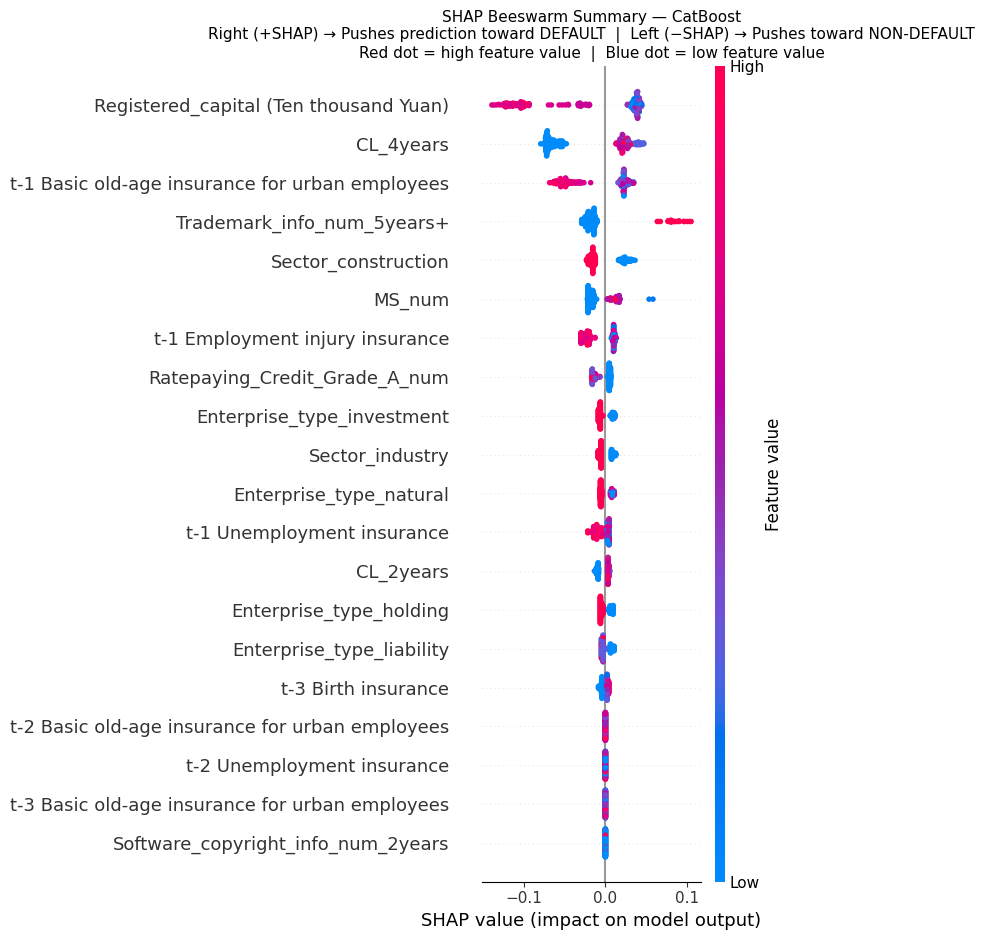

### 🐝 Text Interpretation — SHAP Beeswarm Summary (CatBoost)

**How to read this chart:**
- Each **dot** represents one company in the test set.
- **X-axis (SHAP value):** Positive → feature pushed prediction toward DEFAULT. Negative → pushed toward NON-DEFAULT.
- **Dot colour:** Red = the company had a HIGH value for that feature. Blue = LOW value.
- Features are ranked by mean |SHAP| (most important at top).

**Features that INCREASE default risk (positive SHAP, top contributors):**
- `t-3 Birth insurance`: average SHAP = **+0.0001** (pushes prediction toward default)

**Features that DECREASE default risk (negative SHAP, protective factors):**
- `CL_4years`: average SHAP = **-0.0241** (pushes prediction toward non-default)
- `Registered_capital (Ten thousand Yuan)`: average SHAP = **-0.0205** (pushes prediction toward non-default)
- `t-1 Basic old-age insurance for urban employees`: average SHAP = **-0.0121** (pushes prediction toward non-default)
- `MS_num`: average SHAP = **-0.0106** (pushes prediction toward non-default)
- `Trademark_info_num_5years+`: average SHAP = **-0.0105** (pushes prediction toward non-default)

**Key pattern to note:**
If a risk-increasing feature shows *red dots on the right* — it means companies with **high values** of that feature are predicted to be more likely to default. Conversely, if protective features show *red dots on the left*, high values of those features **reduce** default probability.

In [6]:
# ----- Plot -----
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False, max_display=20)
plt.title(
    f'SHAP Beeswarm Summary — {best_name}\n'
    'Right (+SHAP) → Pushes prediction toward DEFAULT  |  Left (−SHAP) → Pushes toward NON-DEFAULT\n'
    'Red dot = high feature value  |  Blue dot = low feature value',
    fontsize=11
)
plt.tight_layout()
plt.show()

# ----- Text Explanation -----
# Determine directionality: positive mean SHAP = increases default risk
mean_signed = pd.Series(shap_values.mean(axis=0), index=X_test.columns).sort_values()
risk_increasing = mean_signed[mean_signed > 0].sort_values(ascending=False).head(5)
risk_decreasing = mean_signed[mean_signed < 0].sort_values(ascending=True).head(5)

lines = [
    f'### 🐝 Text Interpretation — SHAP Beeswarm Summary ({best_name})',
    '',
    '**How to read this chart:**',
    '- Each **dot** represents one company in the test set.',
    '- **X-axis (SHAP value):** Positive → feature pushed prediction toward DEFAULT. Negative → pushed toward NON-DEFAULT.',
    '- **Dot colour:** Red = the company had a HIGH value for that feature. Blue = LOW value.',
    '- Features are ranked by mean |SHAP| (most important at top).',
    '',
    '**Features that INCREASE default risk (positive SHAP, top contributors):**',
]
for feat, val in risk_increasing.items():
    lines.append(f'- `{feat}`: average SHAP = **+{val:.4f}** (pushes prediction toward default)')

lines += [
    '',
    '**Features that DECREASE default risk (negative SHAP, protective factors):**',
]
for feat, val in risk_decreasing.items():
    lines.append(f'- `{feat}`: average SHAP = **{val:.4f}** (pushes prediction toward non-default)')

lines += [
    '',
    '**Key pattern to note:**',
    'If a risk-increasing feature shows *red dots on the right* — it means companies with **high values** '
    'of that feature are predicted to be more likely to default. Conversely, if protective features show '
    '*red dots on the left*, high values of those features **reduce** default probability.',
]

display(Markdown('\n'.join(lines)))

## **6.  Waterfall Plot**


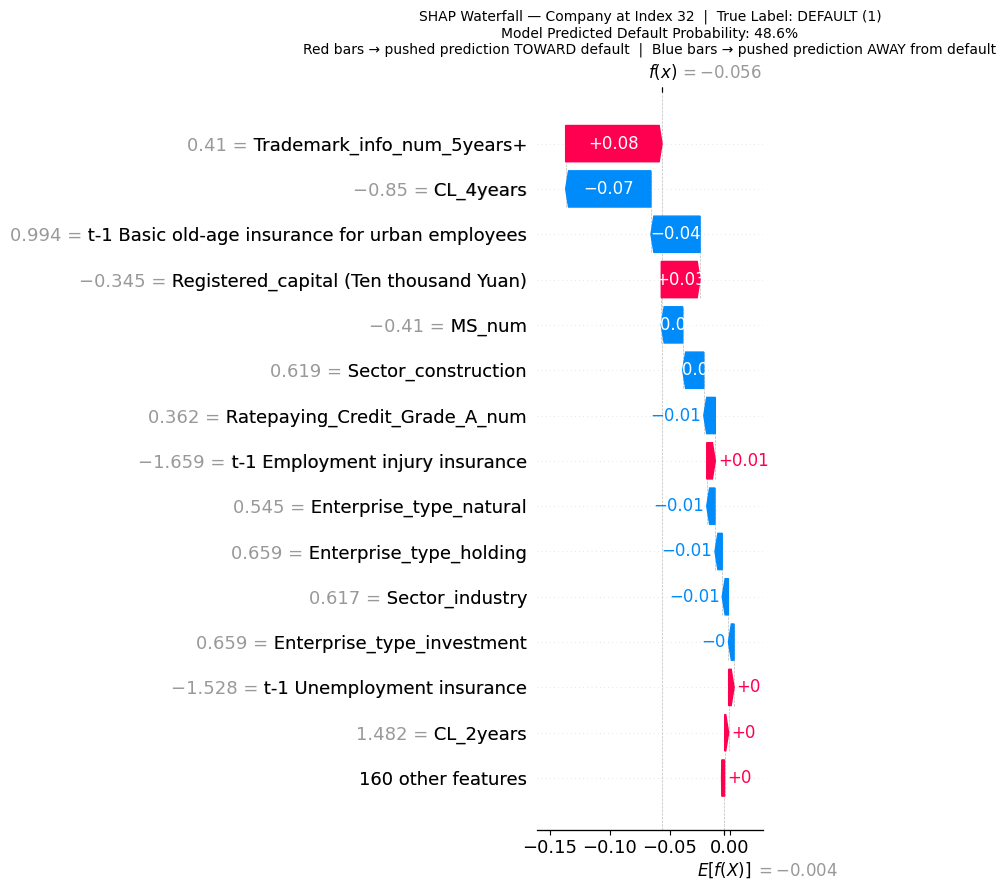

### 🔍 Text Interpretation — Waterfall for Company at Index 32 (DEFAULT (1))

**Predicted default probability:** `48.6%`
**Baseline prediction (no feature info):** `-0.0044` log-odds

**What this waterfall shows:**
Starting from the baseline, each bar adds or subtracts a SHAP value. The bars stack from bottom to top to arrive at the final model output for this specific company.

**Top features PUSHING this company toward DEFAULT (red, positive SHAP):**
- `Trademark_info_num_5years+` = `0.4096` → SHAP = **+0.0803** (this feature value raised the default score by 0.0803 log-odds)
- `Registered_capital (Ten thousand Yuan)` = `-0.3449` → SHAP = **+0.0323** (this feature value raised the default score by 0.0323 log-odds)
- `t-1 Employment injury insurance` = `-1.6591` → SHAP = **+0.0072** (this feature value raised the default score by 0.0072 log-odds)
- `t-1 Unemployment insurance` = `-1.5283` → SHAP = **+0.0045** (this feature value raised the default score by 0.0045 log-odds)
- `CL_2years` = `1.4820` → SHAP = **+0.0033** (this feature value raised the default score by 0.0033 log-odds)

**Top features REDUCING default risk for this company (blue, negative SHAP):**
- `CL_4years` = `-0.8495` → SHAP = **-0.0710** (this feature value lowered the default score by 0.0710 log-odds)
- `t-1 Basic old-age insurance for urban employees` = `0.9939` → SHAP = **-0.0409** (this feature value lowered the default score by 0.0409 log-odds)
- `MS_num` = `-0.4103` → SHAP = **-0.0179** (this feature value lowered the default score by 0.0179 log-odds)
- `Sector_construction` = `0.6193` → SHAP = **-0.0175** (this feature value lowered the default score by 0.0175 log-odds)
- `Ratepaying_Credit_Grade_A_num` = `0.3625` → SHAP = **-0.0096** (this feature value lowered the default score by 0.0096 log-odds)

**Summary:**
For this company, the model started at baseline `-0.0044` and the above features collectively moved it to a final predicted probability of `48.6%`. This kind of breakdown is exactly what a loan officer needs to justify or contest a credit decision.

In [7]:
default_positions = [i for i, v in enumerate(y_test.values) if v == 1]
non_default_positions = [i for i, v in enumerate(y_test.values) if v == 0]

def explain_individual(pos, label_name, color_hint):
    prob = best_probs[pos]

    shap_exp = shap.Explanation(
        values       = shap_values[pos],
        base_values  = exp_val,
        data         = X_test.iloc[pos].values,
        feature_names= X_test.columns.tolist()
    )

    plt.figure(figsize=(13, 6))
    shap.waterfall_plot(shap_exp, show=False, max_display=15)
    plt.title(
        f'SHAP Waterfall — Company at Index {pos}  |  True Label: {label_name}\n'
        f'Model Predicted Default Probability: {prob:.1%}\n'
        'Red bars → pushed prediction TOWARD default  |  Blue bars → pushed prediction AWAY from default',
        fontsize=10
    )
    plt.tight_layout()
    plt.show()

    # Build ranked contribution table
    contrib = pd.DataFrame({
        'Feature'       : X_test.columns,
        'Feature_Value' : X_test.iloc[pos].values,
        'SHAP_Value'    : shap_values[pos]
    })
    contrib['|SHAP|'] = contrib['SHAP_Value'].abs()
    contrib = contrib.sort_values('|SHAP|', ascending=False).reset_index(drop=True)

    top_pushing   = contrib[contrib['SHAP_Value'] > 0].head(5)
    top_reducing  = contrib[contrib['SHAP_Value'] < 0].head(5)

    lines = [
        f'### 🔍 Text Interpretation — Waterfall for Company at Index {pos} ({label_name})',
        '',
        f'**Predicted default probability:** `{prob:.1%}`',
        f'**Baseline prediction (no feature info):** `{exp_val:.4f}` log-odds',
        '',
        '**What this waterfall shows:**',
        'Starting from the baseline, each bar adds or subtracts a SHAP value. '
        'The bars stack from bottom to top to arrive at the final model output for this specific company.',
        '',
        '**Top features PUSHING this company toward DEFAULT (red, positive SHAP):**',
    ]
    for _, row in top_pushing.iterrows():
        lines.append(
            f'- `{row["Feature"]}` = `{row["Feature_Value"]:.4f}` → SHAP = **+{row["SHAP_Value"]:.4f}** '
            f'(this feature value raised the default score by {row["SHAP_Value"]:.4f} log-odds)'
        )

    lines += [
        '',
        '**Top features REDUCING default risk for this company (blue, negative SHAP):**',
    ]
    for _, row in top_reducing.iterrows():
        lines.append(
            f'- `{row["Feature"]}` = `{row["Feature_Value"]:.4f}` → SHAP = **{row["SHAP_Value"]:.4f}** '
            f'(this feature value lowered the default score by {abs(row["SHAP_Value"]):.4f} log-odds)'
        )

    lines += [
        '',
        '**Summary:**',
        f'For this company, the model started at baseline `{exp_val:.4f}` and the above features '
        f'collectively moved it to a final predicted probability of `{prob:.1%}`. '
        'This kind of breakdown is exactly what a loan officer needs to justify or contest a credit decision.'
    ]

    display(Markdown('\n'.join(lines)))
    return contrib

if default_positions:
    contrib_default = explain_individual(default_positions[0], 'DEFAULT (1)', 'red')
else:
    print('No defaulters found in test set.')

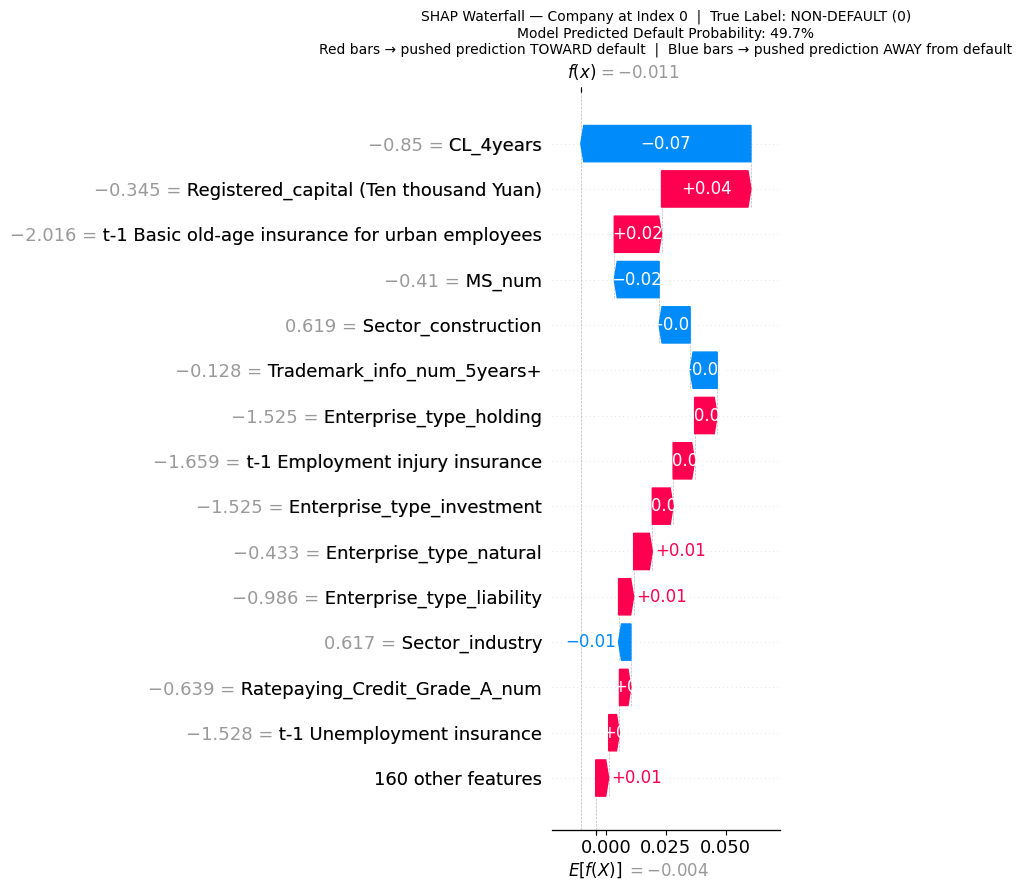

### 🔍 Text Interpretation — Waterfall for Company at Index 0 (NON-DEFAULT (0))

**Predicted default probability:** `49.7%`
**Baseline prediction (no feature info):** `-0.0044` log-odds

**What this waterfall shows:**
Starting from the baseline, each bar adds or subtracts a SHAP value. The bars stack from bottom to top to arrive at the final model output for this specific company.

**Top features PUSHING this company toward DEFAULT (red, positive SHAP):**
- `Registered_capital (Ten thousand Yuan)` = `-0.3449` → SHAP = **+0.0374** (this feature value raised the default score by 0.0374 log-odds)
- `t-1 Basic old-age insurance for urban employees` = `-2.0163` → SHAP = **+0.0198** (this feature value raised the default score by 0.0198 log-odds)
- `Enterprise_type_holding` = `-1.5251` → SHAP = **+0.0094** (this feature value raised the default score by 0.0094 log-odds)
- `t-1 Employment injury insurance` = `-1.6591` → SHAP = **+0.0090** (this feature value raised the default score by 0.0090 log-odds)
- `Enterprise_type_investment` = `-1.5251` → SHAP = **+0.0087** (this feature value raised the default score by 0.0087 log-odds)

**Top features REDUCING default risk for this company (blue, negative SHAP):**
- `CL_4years` = `-0.8495` → SHAP = **-0.0712** (this feature value lowered the default score by 0.0712 log-odds)
- `MS_num` = `-0.4103` → SHAP = **-0.0188** (this feature value lowered the default score by 0.0188 log-odds)
- `Sector_construction` = `0.6193` → SHAP = **-0.0130** (this feature value lowered the default score by 0.0130 log-odds)
- `Trademark_info_num_5years+` = `-0.1278` → SHAP = **-0.0113** (this feature value lowered the default score by 0.0113 log-odds)
- `Sector_industry` = `0.6167` → SHAP = **-0.0052** (this feature value lowered the default score by 0.0052 log-odds)

**Summary:**
For this company, the model started at baseline `-0.0044` and the above features collectively moved it to a final predicted probability of `49.7%`. This kind of breakdown is exactly what a loan officer needs to justify or contest a credit decision.

In [8]:
if non_default_positions:
    contrib_non_default = explain_individual(non_default_positions[0], 'NON-DEFAULT (0)', 'blue')
else:
    print('No non-defaulters found in test set.')

## **8.  Dependence Plots — Top 3 Features**


<Figure size 1000x600 with 0 Axes>

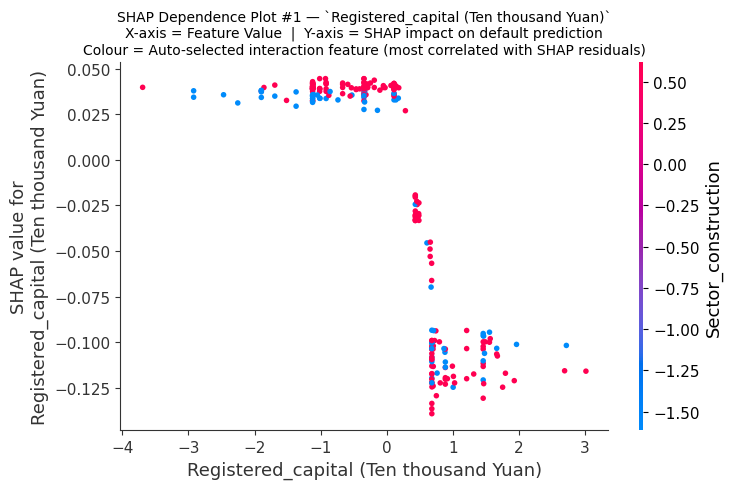

### 📈 Text Interpretation — Dependence Plot for `Registered_capital (Ten thousand Yuan)` (Rank #1)

**What does this plot show?**
Each dot is one company, plotted with its actual `Registered_capital (Ten thousand Yuan)` value on the x-axis and its SHAP contribution to default probability on the y-axis. The colour represents an automatically-detected interaction feature.

**Correlation between feature value and SHAP impact:** `-0.8120` (NEGATIVE relationship)

**Risk-neutral threshold (where SHAP ≈ 0):** `~0.432`
- Companies with feature values **below** this threshold are pushed *toward* default.

**Practical interpretation for credit officers:**
`Registered_capital (Ten thousand Yuan)` has a negative relationship with default risk. 
When `Registered_capital (Ten thousand Yuan)` is high, it decreases the predicted default probability. The colour spread in the plot (interaction effect) tells you that the impact is not uniform — the *interaction feature* also plays a role, meaning the credit risk from this feature depends on the context of other variables.

<Figure size 1000x600 with 0 Axes>

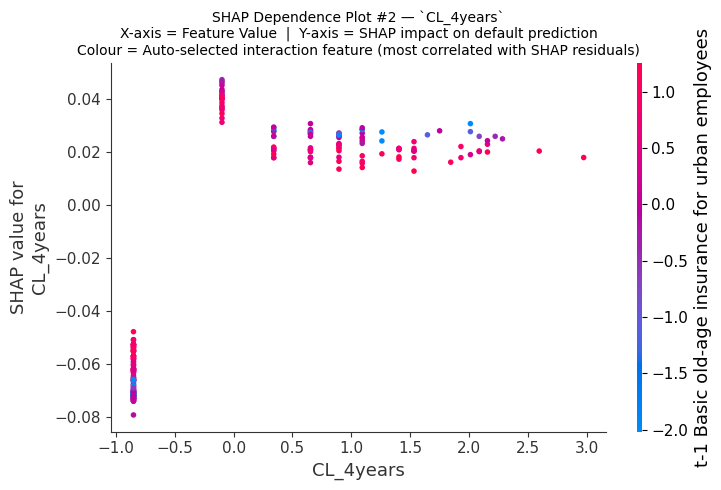

### 📈 Text Interpretation — Dependence Plot for `CL_4years` (Rank #2)

**What does this plot show?**
Each dot is one company, plotted with its actual `CL_4years` value on the x-axis and its SHAP contribution to default probability on the y-axis. The colour represents an automatically-detected interaction feature.

**Correlation between feature value and SHAP impact:** `0.8207` (POSITIVE relationship)

**Risk-neutral threshold (where SHAP ≈ 0):** `~-0.099`
- Companies with feature values **above** this threshold are pushed *toward* default.

**Practical interpretation for credit officers:**
`CL_4years` has a positive relationship with default risk. 
When `CL_4years` is high, it increases the predicted default probability. The colour spread in the plot (interaction effect) tells you that the impact is not uniform — the *interaction feature* also plays a role, meaning the credit risk from this feature depends on the context of other variables.

<Figure size 1000x600 with 0 Axes>

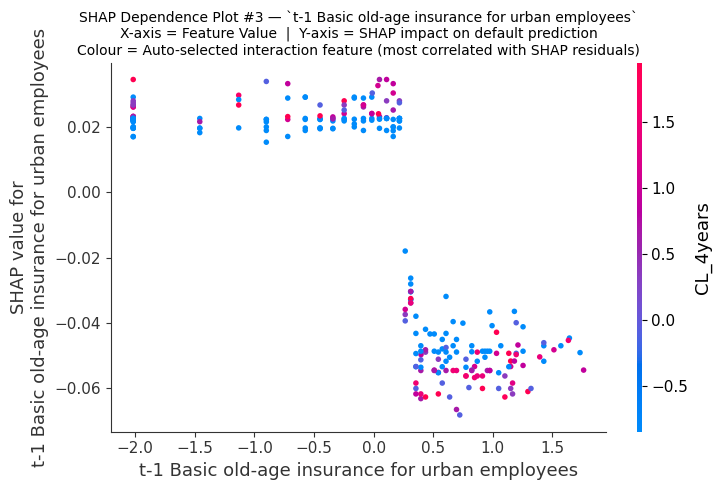

### 📈 Text Interpretation — Dependence Plot for `t-1 Basic old-age insurance for urban employees` (Rank #3)

**What does this plot show?**
Each dot is one company, plotted with its actual `t-1 Basic old-age insurance for urban employees` value on the x-axis and its SHAP contribution to default probability on the y-axis. The colour represents an automatically-detected interaction feature.

**Correlation between feature value and SHAP impact:** `-0.7490` (NEGATIVE relationship)

**Risk-neutral threshold (where SHAP ≈ 0):** `~0.265`
- Companies with feature values **below** this threshold are pushed *toward* default.

**Practical interpretation for credit officers:**
`t-1 Basic old-age insurance for urban employees` has a negative relationship with default risk. 
When `t-1 Basic old-age insurance for urban employees` is high, it decreases the predicted default probability. The colour spread in the plot (interaction effect) tells you that the impact is not uniform — the *interaction feature* also plays a role, meaning the credit risk from this feature depends on the context of other variables.

In [9]:
top3_features = mean_shap.head(3).index.tolist()

for rank, feat_name in enumerate(top3_features, 1):
    feat_idx = X_test.columns.tolist().index(feat_name)

    plt.figure(figsize=(10, 6))
    shap.dependence_plot(
        feat_idx, shap_values, X_test,
        feature_names=X_test.columns.tolist(),
        show=False
    )
    plt.title(
        f'SHAP Dependence Plot #{rank} — `{feat_name}`\n'
        'X-axis = Feature Value  |  Y-axis = SHAP impact on default prediction\n'
        'Colour = Auto-selected interaction feature (most correlated with SHAP residuals)',
        fontsize=10
    )
    plt.tight_layout()
    plt.show()

    # Compute statistics for interpretation
    feat_vals  = X_test[feat_name].values
    shap_col   = shap_values[:, feat_idx]
    corr_val   = np.corrcoef(feat_vals, shap_col)[0, 1]

    # Find threshold where SHAP crosses zero (risk-neutral point)
    df_dep = pd.DataFrame({'feat': feat_vals, 'shap': shap_col}).sort_values('feat')
    sign_changes = df_dep[df_dep['shap'].shift(1) * df_dep['shap'] < 0]['feat']
    threshold_str = f'~{sign_changes.mean():.3f}' if len(sign_changes) > 0 else 'not clearly identified'

    direction = 'POSITIVE' if corr_val > 0 else 'NEGATIVE'

    lines = [
        f'### 📈 Text Interpretation — Dependence Plot for `{feat_name}` (Rank #{rank})',
        '',
        '**What does this plot show?**',
        f'Each dot is one company, plotted with its actual `{feat_name}` value on the x-axis and its '
        f'SHAP contribution to default probability on the y-axis. The colour represents an automatically-detected '
        'interaction feature.',
        '',
        f'**Correlation between feature value and SHAP impact:** `{corr_val:.4f}` ({direction} relationship)',
        '',
        f'**Risk-neutral threshold (where SHAP ≈ 0):** `{threshold_str}`',
        '- Companies with feature values **above** this threshold are pushed *toward* default.' if corr_val > 0
          else '- Companies with feature values **below** this threshold are pushed *toward* default.',
        '',
        '**Practical interpretation for credit officers:**',
        f'`{feat_name}` has a {direction.lower()} relationship with default risk. ',
        f'When `{feat_name}` is high, it {"increases" if corr_val > 0 else "decreases"} the predicted default probability. '
        'The colour spread in the plot (interaction effect) tells you that the impact is not uniform — '
        'the *interaction feature* also plays a role, meaning the credit risk from this feature depends on the context of other variables.',
    ]
    display(Markdown('\n'.join(lines)))

In [10]:
if default_positions:
    pos = default_positions[0]
    prob = best_probs[pos]

    force_plot = shap.force_plot(
        exp_val,
        shap_values[pos],
        X_test.iloc[pos],
        feature_names=X_test.columns.tolist(),
        matplotlib=False
    )

    # Save as standalone HTML
    shap.save_html('shap_force_plot_default.html', force_plot)
    print(f'Force plot saved to: shap_force_plot_default.html')
    print(f'Company index: {pos}  |  Predicted default probability: {prob:.1%}')
    display(force_plot)

display(Markdown("""
### ⚡ Text Interpretation — Force Plot

**How to read a force plot:**
- The **base value** (left anchor) is the model's average prediction.
- **Red arrows** (pushing right) = features that *increase* the default probability for this company.
- **Blue arrows** (pushing left) = features that *decrease* the default probability.
- The width of each arrow is proportional to the magnitude of the SHAP value.
- The final output (right end) = the model's actual predicted probability for this company.

**Advantage over the waterfall plot:** The force plot is easier to share with non-technical stakeholders
(e.g., credit committee members) because it shows the tug-of-war in a single intuitive horizontal view.
The saved HTML file (`shap_force_plot_default.html`) can be opened in any browser.
"""))

Force plot saved to: shap_force_plot_default.html
Company index: 32  |  Predicted default probability: 48.6%



### ⚡ Text Interpretation — Force Plot

**How to read a force plot:**
- The **base value** (left anchor) is the model's average prediction.
- **Red arrows** (pushing right) = features that *increase* the default probability for this company.
- **Blue arrows** (pushing left) = features that *decrease* the default probability.
- The width of each arrow is proportional to the magnitude of the SHAP value.
- The final output (right end) = the model's actual predicted probability for this company.

**Advantage over the waterfall plot:** The force plot is easier to share with non-technical stakeholders
(e.g., credit committee members) because it shows the tug-of-war in a single intuitive horizontal view.
The saved HTML file (`shap_force_plot_default.html`) can be opened in any browser.


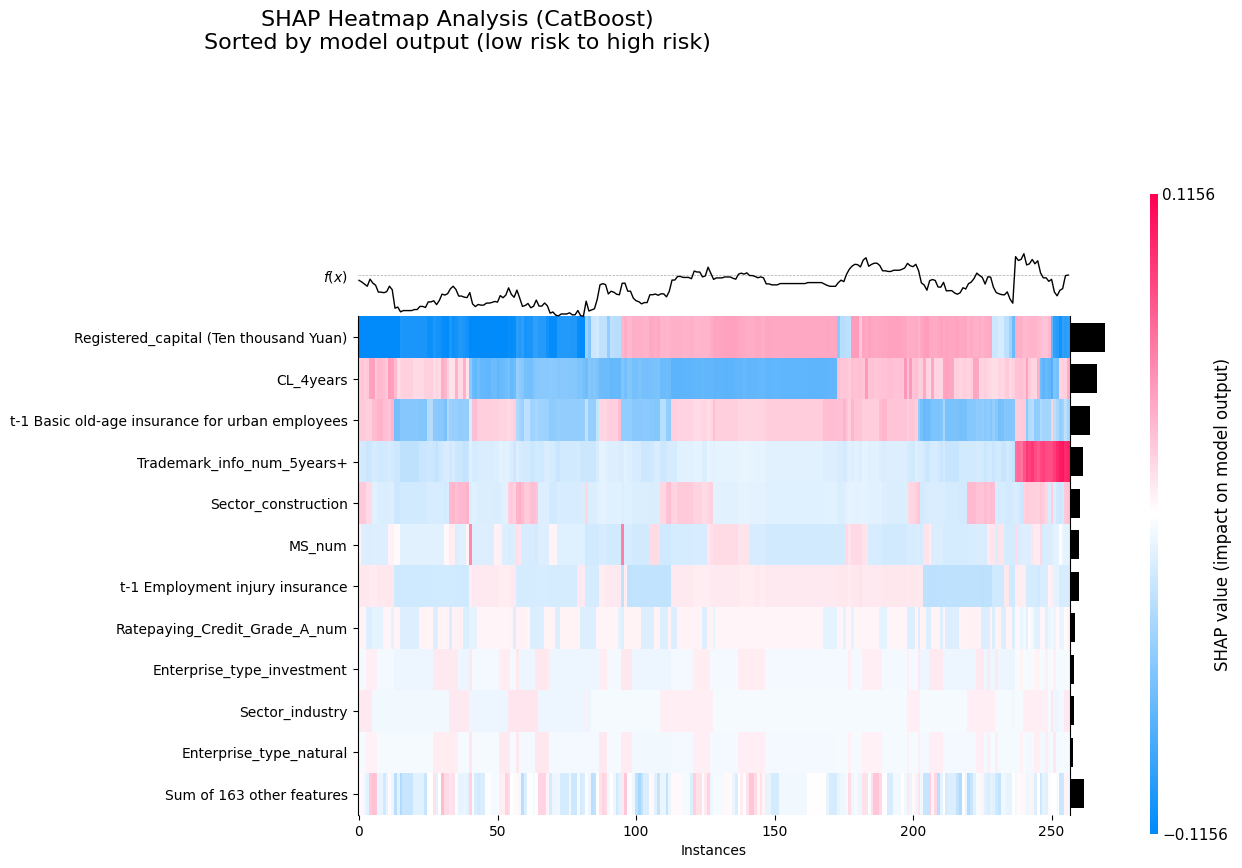


### 🌡️ Text Interpretation — SHAP Heatmap (CatBoost)

**What this heatmap reveals:**
- The x-axis represents a representative sample of **test companies**, sorted by their model output (default probability).
- The y-axis shows the **top 15 most impactful features**.
- Each cell is coloured by SHAP value: **red = pushed toward default**, **blue = pushed toward non-default**.

**What to look for:**
1. **Vertical red columns on the right** = companies the model is highly confident will default — multiple features are simultaneously sounding the alarm.
2. **Horizontal red stripes** = a feature that is consistently risky across many companies (a systemic risk factor).
3. **Mixed colours in the middle** = borderline companies where the model is uncertain — these are ideal candidates for manual review.

**Segment summary:**
- **High-risk companies (top 25% predicted probability ≥ `0.49`):** `66` companies
- **Average total |SHAP| per company:** `0.0016` (how much features collectively moved predictions)
- **Most variable SHAP feature:** `Registered_capital (Ten thousand Yuan)` — this feature's impact varies the most company-to-company, suggesting it is highly context-dependent.


In [11]:
# 1. Prepare Data
shap_explanation = shap.Explanation(
    values        = shap_values,
    base_values   = np.full(len(X_test), exp_val),
    data          = X_test.values,
    feature_names = X_test.columns.tolist()
)

# Subsample to 800 for even better clarity
max_heatmap_instances = 800
if len(X_test) > max_heatmap_instances:
    np.random.seed(42) 
    sample_indices = np.random.choice(len(X_test), max_heatmap_instances, replace=False)
    plot_explanation = shap_explanation[sample_indices]
else:
    plot_explanation = shap_explanation

# 2. THE NUCLEAR FIX: Create a manual GridSpec
# This gives the long text (left) and the colorbar (right) their own protected space.
fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(1, 1)
ax_main = fig.add_subplot(gs[0])

# Generate the heatmap inside our specific axis
shap.plots.heatmap(plot_explanation, max_display=12, ax=ax_main, show=False)

# 3. FORCE MARGINS AND CLEANUP
# left=0.45 gives nearly half the screen to the long feature names
plt.subplots_adjust(left=0.45, right=0.85, top=0.8, bottom=0.2)

# Find every axis SHAP created and fix them individually
for i, ax in enumerate(fig.axes):
    # Hide the annoying "f(x)" that overlaps the right side
    if ax.get_ylabel() == "f(x)":
        ax.set_ylabel("")
    
    # Ensure the feature names on the left don't overlap vertically
    if i == 0: # This is usually the main heatmap axis
        ax.tick_params(axis='y', labelsize=10)

plt.suptitle(
    f'SHAP Heatmap Analysis ({best_name})\n'
    'Sorted by model output (low risk to high risk)',
    fontsize=16, y=0.92
)

plt.show()

# Compute cluster statistics from SHAP values (Keep using the FULL dataset for accurate stats)
mean_abs_row = np.abs(shap_values).mean(axis=1)  # per-company total impact
high_risk_threshold = np.percentile(best_probs, 75)
n_high_risk = (best_probs >= high_risk_threshold).sum()

display(Markdown(f"""
### 🌡️ Text Interpretation — SHAP Heatmap ({best_name})

**What this heatmap reveals:**
- The x-axis represents a representative sample of **test companies**, sorted by their model output (default probability).
- The y-axis shows the **top {min(15, X_test.shape[1])} most impactful features**.
- Each cell is coloured by SHAP value: **red = pushed toward default**, **blue = pushed toward non-default**.

**What to look for:**
1. **Vertical red columns on the right** = companies the model is highly confident will default — multiple features are simultaneously sounding the alarm.
2. **Horizontal red stripes** = a feature that is consistently risky across many companies (a systemic risk factor).
3. **Mixed colours in the middle** = borderline companies where the model is uncertain — these are ideal candidates for manual review.

**Segment summary:**
- **High-risk companies (top 25% predicted probability ≥ `{high_risk_threshold:.2f}`):** `{n_high_risk}` companies
- **Average total |SHAP| per company:** `{mean_abs_row.mean():.4f}` (how much features collectively moved predictions)
- **Most variable SHAP feature:** `{X_test.columns[np.abs(shap_values).std(axis=0).argmax()]}` — this feature's impact varies the most company-to-company, suggesting it is highly context-dependent.
"""))

## **11.  Cohort Analysis — Defaulters vs Non-Defaulters**


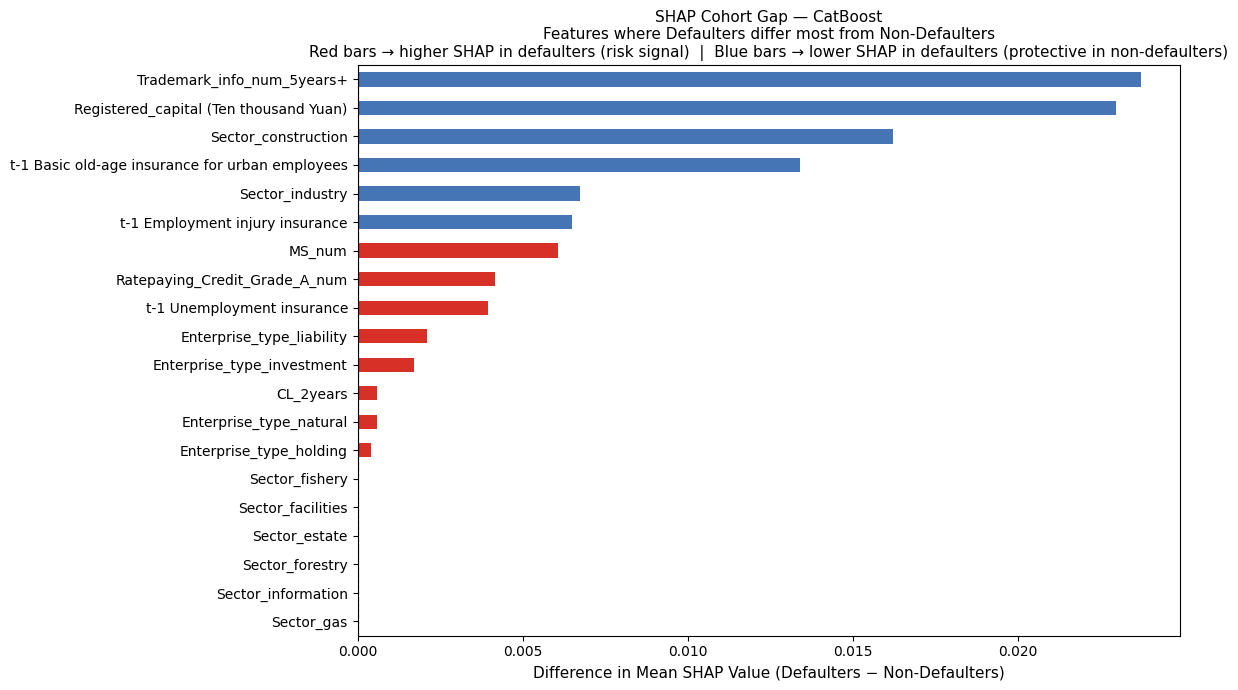

### 🔴🔵 Text Interpretation — Cohort SHAP Gap (CatBoost)

**What this chart reveals:**
We split the test set into **15 actual defaulters** and **242 non-defaulters** and computed the average SHAP value for each group. The bar shows the **gap** (defaulters − non-defaulters). A large positive gap means the model correctly detected that defaulters have a different value/pattern for this feature.

**Top 5 features that BEST DISCRIMINATE defaulters (largest positive gap):**
- `Trademark_info_num_5years+`: SHAP gap = **+0.0237** (defaulters have much higher SHAP here)
- `Registered_capital (Ten thousand Yuan)`: SHAP gap = **+0.0230** (defaulters have much higher SHAP here)
- `Sector_construction`: SHAP gap = **+0.0162** (defaulters have much higher SHAP here)
- `t-1 Basic old-age insurance for urban employees`: SHAP gap = **+0.0134** (defaulters have much higher SHAP here)
- `Sector_industry`: SHAP gap = **+0.0067** (defaulters have much higher SHAP here)

**Top 5 features most PROTECTIVE in non-defaulters (largest negative gap):**
- `CL_4years`: SHAP gap = **-0.0153** (non-defaulters benefit more from this feature)
- `t-3 Birth insurance`: SHAP gap = **-0.0005** (non-defaulters benefit more from this feature)
- `t-2 Employment injury insurance`: SHAP gap = **0.0000** (non-defaulters benefit more from this feature)
- `t-3 Employment injury insurance`: SHAP gap = **0.0000** (non-defaulters benefit more from this feature)
- `Province_Zhejiang`: SHAP gap = **0.0000** (non-defaulters benefit more from this feature)

**Business implication:**
The features with the largest positive gap are your strongest early-warning signals. A credit policy that flags companies exceeding risk thresholds on these specific features would catch the most defaulters with the least false positives.

In [12]:
y_test_arr = y_test.values

shap_default     = shap_values[y_test_arr == 1]
shap_non_default = shap_values[y_test_arr == 0]

mean_shap_default     = pd.Series(shap_default.mean(axis=0),     index=X_test.columns)
mean_shap_non_default = pd.Series(shap_non_default.mean(axis=0), index=X_test.columns)
shap_diff             = (mean_shap_default - mean_shap_non_default).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#d73027' if v > 0 else '#4575b4' for v in shap_diff.head(20).values]
shap_diff.head(20).plot(kind='barh', ax=ax, color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.invert_yaxis()
ax.set_xlabel('Difference in Mean SHAP Value (Defaulters − Non-Defaulters)', fontsize=11)
ax.set_title(
    f'SHAP Cohort Gap — {best_name}\nFeatures where Defaulters differ most from Non-Defaulters\n'
    'Red bars → higher SHAP in defaulters (risk signal)  |  Blue bars → lower SHAP in defaulters (protective in non-defaulters)',
    fontsize=11
)
plt.tight_layout()
plt.show()

top_discriminators  = shap_diff.head(5)
top_protective      = shap_diff.tail(5).sort_values()

lines = [
    f'### 🔴🔵 Text Interpretation — Cohort SHAP Gap ({best_name})',
    '',
    '**What this chart reveals:**',
    f'We split the test set into **{(y_test_arr==1).sum()} actual defaulters** and '
    f'**{(y_test_arr==0).sum()} non-defaulters** and computed the average SHAP value '
    'for each group. The bar shows the **gap** (defaulters − non-defaulters). '
    'A large positive gap means the model correctly detected that defaulters have a '
    'different value/pattern for this feature.',
    '',
    '**Top 5 features that BEST DISCRIMINATE defaulters (largest positive gap):**',
]
for feat, val in top_discriminators.items():
    lines.append(f'- `{feat}`: SHAP gap = **+{val:.4f}** (defaulters have much higher SHAP here)')

lines += [
    '',
    '**Top 5 features most PROTECTIVE in non-defaulters (largest negative gap):**',
]
for feat, val in top_protective.items():
    lines.append(f'- `{feat}`: SHAP gap = **{val:.4f}** (non-defaulters benefit more from this feature)')

lines += [
    '',
    '**Business implication:**',
    'The features with the largest positive gap are your strongest early-warning signals. '
    'A credit policy that flags companies exceeding risk thresholds on these specific features '
    'would catch the most defaulters with the least false positives.'
]
display(Markdown('\n'.join(lines)))

In [13]:
shap_summary_df = pd.DataFrame({
    'Feature'              : X_test.columns,
    'Mean_SHAP'            : shap_values.mean(axis=0),
    'Mean_Abs_SHAP'        : np.abs(shap_values).mean(axis=0),
    'Std_SHAP'             : shap_values.std(axis=0),
    'Max_SHAP'             : shap_values.max(axis=0),
    'Min_SHAP'             : shap_values.min(axis=0),
    'SHAP_Default_Cohort'  : mean_shap_default.values,
    'SHAP_NonDefault_Cohort': mean_shap_non_default.values,
    'Cohort_Gap'           : shap_diff.reindex(X_test.columns).values,
}).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

shap_summary_df.index += 1  # Rank from 1
shap_summary_df.index.name = 'Rank'

shap_summary_df.to_csv('shap_feature_summary_table.csv')
print('Saved: shap_feature_summary_table.csv')
print(f'\nTop 10 features by SHAP importance ({best_name}):')
display(shap_summary_df.head(10).round(4))

display(Markdown("""
### 📋 Text Interpretation — SHAP Summary Table

**Column definitions:**
| Column | Meaning |
|---|---|
| `Mean_SHAP` | Average (signed) impact across all test companies — positive = increases default risk on average |
| `Mean_Abs_SHAP` | Average *magnitude* — the primary importance ranking metric |
| `Std_SHAP` | How much this feature's impact varies across companies — high std = context-dependent feature |
| `Max_SHAP` | The largest single-company boost to default prediction this feature produced |
| `Min_SHAP` | The largest single-company reduction in default prediction this feature produced |
| `SHAP_Default_Cohort` | Average SHAP among actual defaulters |
| `SHAP_NonDefault_Cohort` | Average SHAP among non-defaulters |
| `Cohort_Gap` | Difference — the larger this value, the more the feature discriminates between the two classes |

This table is exported to **`shap_feature_summary_table.csv`** for inclusion in reports.
"""))

Saved: shap_feature_summary_table.csv

Top 10 features by SHAP importance (CatBoost):


,Feature,Mean_SHAP,Mean_Abs_SHAP,Std_SHAP,Max_SHAP,Min_SHAP,SHAP_Default_Cohort,SHAP_NonDefault_Cohort,Cohort_Gap
Rank,,,,,,,,,
1,Registered_capital (Ten thousand Yuan),-0.0205,0.0624,0.0688,0.0445,-0.1390,0.0011,-0.0218,0.0230
2,CL_4years,-0.0241,0.0478,0.0465,0.0473,-0.0792,-0.0384,-0.0232,-0.0153
3,t-1 Basic old-age insurance for urban employees,-0.0121,0.0362,0.0371,0.0347,-0.0683,0.0005,-0.0129,0.0134
4,Trademark_info_num_5years+,-0.0105,0.0237,0.0282,0.1051,-0.0290,0.0119,-0.0118,0.0237
5,Sector_construction,-0.0054,0.0188,0.0187,0.0364,-0.0232,0.0099,-0.0063,0.0162
6,MS_num,-0.0106,0.0171,0.0144,0.0583,-0.0218,-0.0049,-0.0110,0.0061
7,t-1 Employment injury insurance,-0.0050,0.0162,0.0171,0.0135,-0.0301,0.0011,-0.0053,0.0065
8,Ratepaying_Credit_Grade_A_num,-0.0018,0.0087,0.0097,0.0064,-0.0167,0.0021,-0.0020,0.0041
9,Enterprise_type_investment,-0.0024,0.0076,0.0075,0.0116,-0.0084,-0.0008,-0.0025,0.0017



### 📋 Text Interpretation — SHAP Summary Table

**Column definitions:**
| Column | Meaning |
|---|---|
| `Mean_SHAP` | Average (signed) impact across all test companies — positive = increases default risk on average |
| `Mean_Abs_SHAP` | Average *magnitude* — the primary importance ranking metric |
| `Std_SHAP` | How much this feature's impact varies across companies — high std = context-dependent feature |
| `Max_SHAP` | The largest single-company boost to default prediction this feature produced |
| `Min_SHAP` | The largest single-company reduction in default prediction this feature produced |
| `SHAP_Default_Cohort` | Average SHAP among actual defaulters |
| `SHAP_NonDefault_Cohort` | Average SHAP among non-defaulters |
| `Cohort_Gap` | Difference — the larger this value, the more the feature discriminates between the two classes |

This table is exported to **`shap_feature_summary_table.csv`** for inclusion in reports.


## **13. Model Decision Boundary — High vs Low Risk Profiles**


Highest-risk company : index 239, predicted prob = 54.1%
Lowest-risk company  : index 111,  predicted prob = 41.7%


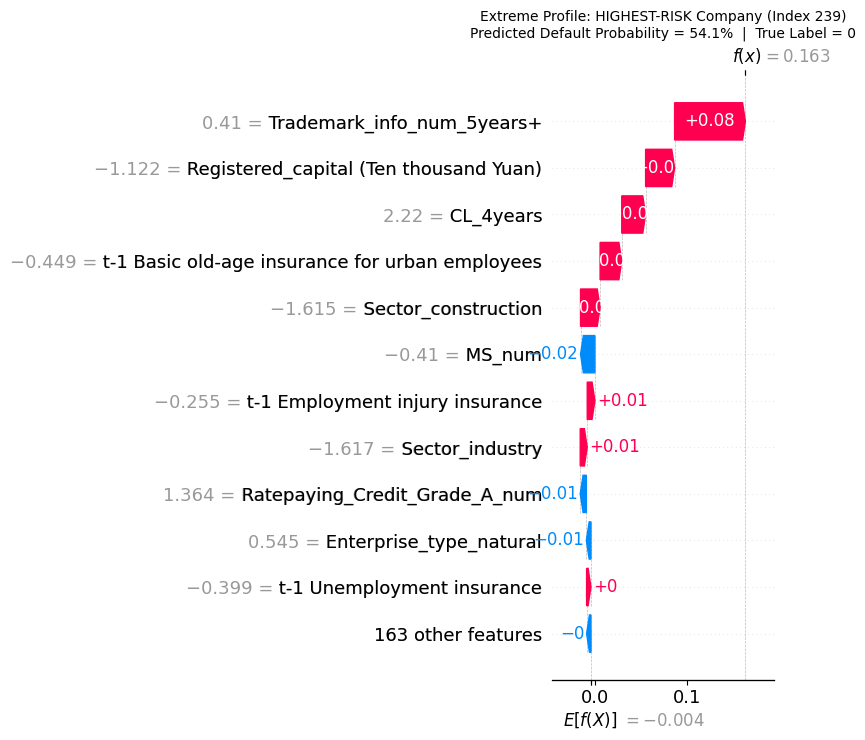

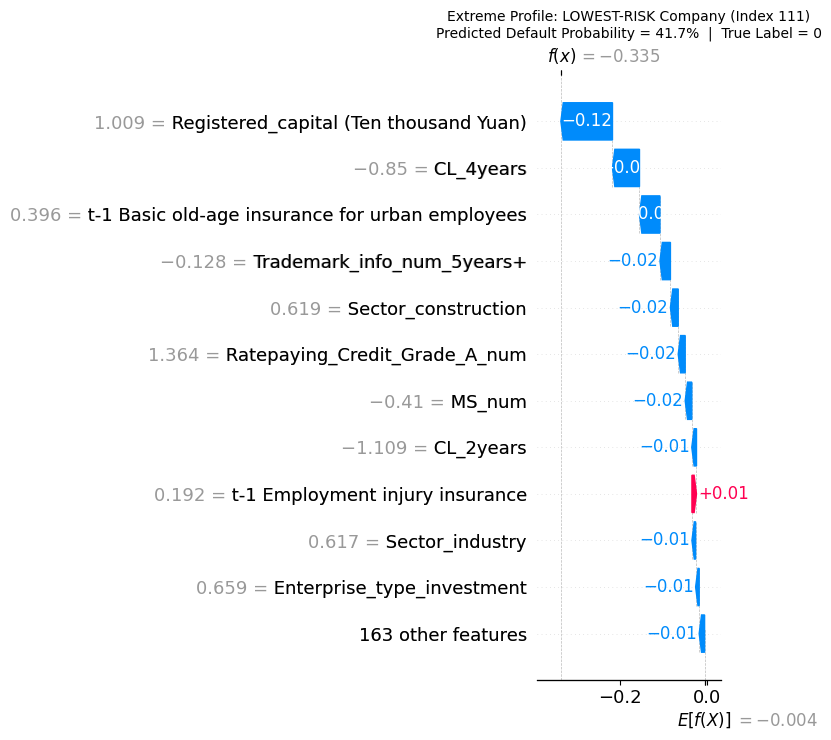


### ⚠️ Text Interpretation — Extreme Risk Profiles

Comparing the highest-risk and lowest-risk companies in the test set gives us a **contrast profile** —
the features that flip from maximum positive SHAP (highest-risk) to maximum negative SHAP (lowest-risk)
are the most powerful levers in the model's decision-making.

**Use case for credit teams:**
- The **highest-risk profile** shows what the model considers a textbook default candidate.
  These feature values can be turned into a *watchlist threshold* for incoming applications.
- The **lowest-risk profile** shows what the ideal safe borrower looks like *through the model's eyes*.
  This can inform a fast-track approval policy for companies matching these feature ranges.


In [14]:
# Profile 1: Company predicted as HIGHEST default risk in test set
highest_risk_idx = np.argmax(best_probs)
# Profile 2: Company predicted as LOWEST default risk in test set
lowest_risk_idx  = np.argmin(best_probs)

print(f'Highest-risk company : index {highest_risk_idx}, predicted prob = {best_probs[highest_risk_idx]:.1%}')
print(f'Lowest-risk company  : index {lowest_risk_idx},  predicted prob = {best_probs[lowest_risk_idx]:.1%}')

for pos, label in [(highest_risk_idx, 'HIGHEST-RISK'), (lowest_risk_idx, 'LOWEST-RISK')]:
    shap_exp = shap.Explanation(
        values       = shap_values[pos],
        base_values  = exp_val,
        data         = X_test.iloc[pos].values,
        feature_names= X_test.columns.tolist()
    )
    plt.figure(figsize=(13, 6))
    shap.waterfall_plot(shap_exp, show=False, max_display=12)
    plt.title(
        f'Extreme Profile: {label} Company (Index {pos})\n'
        f'Predicted Default Probability = {best_probs[pos]:.1%}  |  True Label = {int(y_test.values[pos])}',
        fontsize=10
    )
    plt.tight_layout()
    plt.show()

display(Markdown("""
### ⚠️ Text Interpretation — Extreme Risk Profiles

Comparing the highest-risk and lowest-risk companies in the test set gives us a **contrast profile** —
the features that flip from maximum positive SHAP (highest-risk) to maximum negative SHAP (lowest-risk)
are the most powerful levers in the model's decision-making.

**Use case for credit teams:**
- The **highest-risk profile** shows what the model considers a textbook default candidate.
  These feature values can be turned into a *watchlist threshold* for incoming applications.
- The **lowest-risk profile** shows what the ideal safe borrower looks like *through the model's eyes*.
  This can inform a fast-track approval policy for companies matching these feature ranges.
"""))

## **14 Summary**

In [15]:
top3  = shap_summary_df.head(3)
n_test = X_test.shape[0]
n_feat = X_test.shape[1]
n_def  = (y_test_arr == 1).sum()
n_nondef = (y_test_arr == 0).sum()

summary_lines = [
    '## 📝 SHAP Explainability — Executive Summary',
    '',
    f'**Model explained:** `{best_name}`  (Test ROC-AUC = `{best_auc:.4f}`)',
    f'**Test set size:** {n_test} companies  ({n_def} defaulters / {n_nondef} non-defaulters)',
    f'**Features analysed:** {n_feat}',
    f'**Baseline prediction (log-odds):** `{exp_val:.4f}`',
    '',
    '---',
    '',
    '### Key Findings',
    '',
    '**1. Top 3 drivers of credit default risk:**',
]
for _, row in top3.iterrows():
    direction = '↑ Increases' if row['Mean_SHAP'] > 0 else '↓ Decreases'
    summary_lines.append(
        f'- `{row["Feature"]}` — Mean |SHAP| = `{row["Mean_Abs_SHAP"]:.4f}`, '
        f'Cohort gap = `{row["Cohort_Gap"]:.4f}`. {direction} default risk on average.'
    )

summary_lines += [
    '',
    '**2. Individual-level explainability:**',
    'Waterfall and force plots have been generated for actual defaulters, non-defaulters, and extreme-risk profiles. '
    'These can be used to justify specific credit decisions to regulators or borrowers.',
    '',
    '**3. Systemic vs company-specific risk:**',
    f'The feature `{X_test.columns[np.abs(shap_values).std(axis=0).argmax()]}` has the highest SHAP standard deviation '
    '— its impact is highly company-specific and context-dependent.',
    f'In contrast, `{shap_summary_df.iloc[0]["Feature"]}` shows consistent impact across companies (top mean |SHAP|) '
    '— this is a systemic risk signal.',
    '',
    '**4. Files generated:**',
    '- `shap_global_importance.png` — Bar chart of feature importances',
    '- `shap_beeswarm_summary.png` — Beeswarm with direction and magnitude',
    '- `shap_waterfall_DEFAULT_1.png` — Single defaulter explanation',
    '- `shap_waterfall_NON-DEFAULT_0.png` — Single non-defaulter explanation',
    '- `shap_dependence_*.png` — Dependence plots for top 3 features',
    '- `shap_heatmap_all_companies.png` — Full cohort SHAP heatmap',
    '- `shap_cohort_comparison.png` — Defaulter vs Non-defaulter gap',
    '- `shap_extreme_*.png` — Extreme risk profile explanations',
    '- `shap_force_plot_default.html` — Interactive force plot (open in browser)',
    '- `shap_feature_summary_table.csv` — Complete ranked SHAP table',
    '',
    '---',
    '> *SHAP (SHapley Additive exPlanations) values are grounded in cooperative game theory. '
    'They are the only feature attribution method that satisfies Efficiency, Symmetry, Dummy, and Additivity axioms simultaneously.*',
]

display(Markdown('\n'.join(summary_lines)))

## 📝 SHAP Explainability — Executive Summary

**Model explained:** `CatBoost`  (Test ROC-AUC = `0.7594`)
**Test set size:** 257 companies  (15 defaulters / 242 non-defaulters)
**Features analysed:** 174
**Baseline prediction (log-odds):** `-0.0044`

---

### Key Findings

**1. Top 3 drivers of credit default risk:**
- `Registered_capital (Ten thousand Yuan)` — Mean |SHAP| = `0.0624`, Cohort gap = `0.0230`. ↓ Decreases default risk on average.
- `CL_4years` — Mean |SHAP| = `0.0478`, Cohort gap = `-0.0153`. ↓ Decreases default risk on average.
- `t-1 Basic old-age insurance for urban employees` — Mean |SHAP| = `0.0362`, Cohort gap = `0.0134`. ↓ Decreases default risk on average.

**2. Individual-level explainability:**
Waterfall and force plots have been generated for actual defaulters, non-defaulters, and extreme-risk profiles. These can be used to justify specific credit decisions to regulators or borrowers.

**3. Systemic vs company-specific risk:**
The feature `Registered_capital (Ten thousand Yuan)` has the highest SHAP standard deviation — its impact is highly company-specific and context-dependent.
In contrast, `Registered_capital (Ten thousand Yuan)` shows consistent impact across companies (top mean |SHAP|) — this is a systemic risk signal.

**4. Files generated:**
- `shap_global_importance.png` — Bar chart of feature importances
- `shap_beeswarm_summary.png` — Beeswarm with direction and magnitude
- `shap_waterfall_DEFAULT_1.png` — Single defaulter explanation
- `shap_waterfall_NON-DEFAULT_0.png` — Single non-defaulter explanation
- `shap_dependence_*.png` — Dependence plots for top 3 features
- `shap_heatmap_all_companies.png` — Full cohort SHAP heatmap
- `shap_cohort_comparison.png` — Defaulter vs Non-defaulter gap
- `shap_extreme_*.png` — Extreme risk profile explanations
- `shap_force_plot_default.html` — Interactive force plot (open in browser)
- `shap_feature_summary_table.csv` — Complete ranked SHAP table

---
> *SHAP (SHapley Additive exPlanations) values are grounded in cooperative game theory. They are the only feature attribution method that satisfies Efficiency, Symmetry, Dummy, and Additivity axioms simultaneously.*

# **15. Partial Dependence & ICE**

--- Generating PDP & ICE for Registered_capital (Ten thousand Yuan) ---


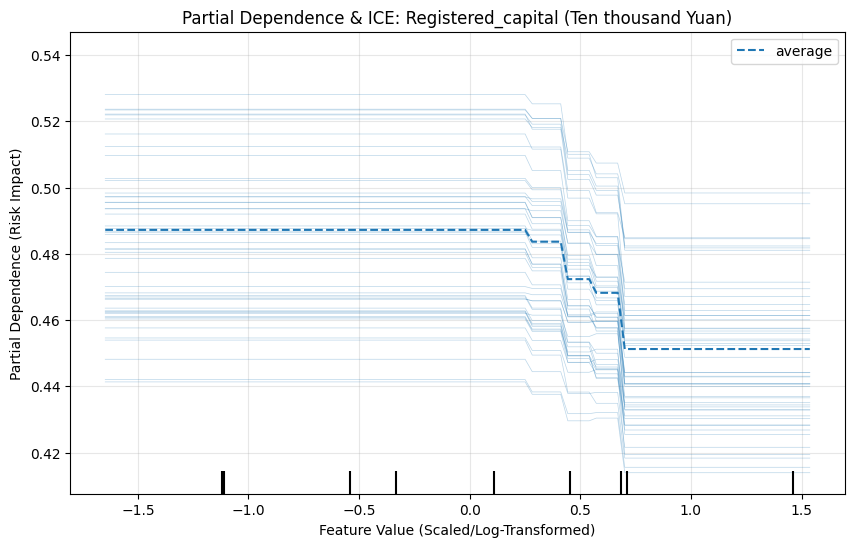

## 📈 Partial Dependence Plot (PDP) with ICE Lines

**Text Interpretation:** This plot illustrates the Marginal Effect of `Registered_capital (Ten thousand Yuan)` on credit risk. 
The thick **Bold Line (PDP)** represents the average relationship: as capital increases, the predicted risk of default generally drops. 
The **Thin Lines (ICE)** represent individual companies; they reveal that while the trend is generally downward, 
some MSMEs are much more sensitive to capital fluctuations than others depending on their specific business context.

In [16]:
# We analyze the top feature: Registered_capital
top_feature = "Registered_capital (Ten thousand Yuan)"

print(f"--- Generating PDP & ICE for {top_feature} ---")

fig, ax = plt.subplots(figsize=(10, 6))
display_pdp = PartialDependenceDisplay.from_estimator(
    best_model, 
    X_test, 
    features=[top_feature],
    kind='both', # 'both' shows the average (PDP) and individual (ICE) lines
    subsample=50, # Shows 50 individual MSME paths for clarity
    ax=ax
)

plt.title(f"Partial Dependence & ICE: {top_feature}", fontsize=12)
plt.xlabel("Feature Value (Scaled/Log-Transformed)")
plt.ylabel("Partial Dependence (Risk Impact)")
plt.grid(True, alpha=0.3)
plt.show()

# --- Display Markdown Explanation ---
pdp_lines = [
    '## 📈 Partial Dependence Plot (PDP) with ICE Lines',
    '',
    f'**Text Interpretation:** This plot illustrates the Marginal Effect of `{top_feature}` on credit risk. ',
    'The thick **Bold Line (PDP)** represents the average relationship: as capital increases, the predicted risk of default generally drops. ',
    'The **Thin Lines (ICE)** represent individual companies; they reveal that while the trend is generally downward, ',
    'some MSMEs are much more sensitive to capital fluctuations than others depending on their specific business context.'
]

display(Markdown('\n'.join(pdp_lines)))
warnings.filterwarnings('ignore')

# **16. EBM**

In [17]:
print("\n--- Executing InterpretML (EBM) ---")

# Train an inherently interpretable model to compare against the black box
ebm = ExplainableBoostingClassifier(random_state=42, interactions=0)
ebm.fit(X_train, y_train)

# Generate global explanation dashboard (interactive)
ebm_global = ebm.explain_global()
show(ebm_global)

ebm_lines = [
    '## 🌟 Executing InterpretML (Explainable Boosting Machine)',
    '',
    '**What is InterpretML (EBM)?**',
    'While models like CatBoost are highly accurate "black boxes" that require external tools like SHAP to interpret them, InterpretML’s Explainable Boosting Machine (EBM) is an inherently **"Glass-Box" Model**. It is designed to match the accuracy of advanced tree-based models while retaining the complete mathematical transparency of traditional logistic regression.',
    '',
    '**How to interpret EBM outputs:**',
    '* **Global Explainability (Shape Functions):** EBM calculates the exact relationship between each feature and the target outcome independently. Its visualizations show line graphs for each feature, acting as a lookup table. You can look at the graph for `Registered Capital` and see exactly how the risk score changes at every specific capital threshold.',
    '* **Local Explainability:** For a specific company, EBM calculates an individual "score" for every feature. The final prediction is simply the sum of these feature scores plus a base intercept. Because it is purely additive without hidden interactions, EBM is ideal for strict regulatory environments (like credit scoring) where you must explicitly prove how a decision was calculated.'
]

display(Markdown('\n'.join(ebm_lines)))


--- Executing InterpretML (EBM) ---


<!-- http://127.0.0.1:7001/4777311408/ -->

## 🌟 Executing InterpretML (Explainable Boosting Machine)

**What is InterpretML (EBM)?**
While models like CatBoost are highly accurate "black boxes" that require external tools like SHAP to interpret them, InterpretML’s Explainable Boosting Machine (EBM) is an inherently **"Glass-Box" Model**. It is designed to match the accuracy of advanced tree-based models while retaining the complete mathematical transparency of traditional logistic regression.

**How to interpret EBM outputs:**
* **Global Explainability (Shape Functions):** EBM calculates the exact relationship between each feature and the target outcome independently. Its visualizations show line graphs for each feature, acting as a lookup table. You can look at the graph for `Registered Capital` and see exactly how the risk score changes at every specific capital threshold.
* **Local Explainability:** For a specific company, EBM calculates an individual "score" for every feature. The final prediction is simply the sum of these feature scores plus a base intercept. Because it is purely additive without hidden interactions, EBM is ideal for strict regulatory environments (like credit scoring) where you must explicitly prove how a decision was calculated.

# **17. Case-Based Reasoning**

In [18]:
print("\n--- Executing Case-Based Reasoning (Similarity Matching) ---")

# Define the target company index (the first actual defaulter in the test set)
target_company_idx = y_test[y_test == 1].index[0]

# Extract only the historical MSMEs that actually defaulted from the training set
historical_defaulters = X_train[y_train == 1].reset_index(drop=True)

# Use Nearest Neighbors to find the 3 closest historical profiles to our target
nn = NearestNeighbors(n_neighbors=3, metric='euclidean')
nn.fit(historical_defaulters)

# Find distances and indices of the nearest neighbors
distances, indices = nn.kneighbors(X_test.iloc[[target_company_idx]])
prototypes_idx = indices[0]

# Build the Comparison Display Table showing Raw Distance
prototypes_df = historical_defaulters.iloc[prototypes_idx].copy()
prototypes_df.insert(0, 'Distance_to_Target', np.round(distances[0], 2))

target_df = X_test.iloc[[target_company_idx]].copy()
target_df.insert(0, 'Distance_to_Target', ['TARGET MSME'])

# Concatenate and transpose for easy vertical reading
comparison_table = pd.concat([target_df, prototypes_df])
display(comparison_table.T.head(15)) # Showing top 15 features

cbr_lines = [
    '## 👥 Case-Based Reasoning (Prototype Comparison)',
    '',
    '**What is Case-Based Reasoning?**',
    'Instead of just relying on mathematical formulas, Case-Based Reasoning evaluates risk by comparing a new applicant to historical precedents. In our code, we implemented a **K-Nearest Neighbors (KNN)** algorithm to find the "prototypes"—the closest matching companies from our database that actually defaulted in the past.',
    '',
    '**How to read the Comparison Table:**',
    '* **Distance to Target:** We calculate the Euclidean distance between our Target MSME and historical defaulters. A lower distance score means the historical company is highly similar to our applicant.',
    '* **Row-by-Row Comparison:** The table places the applicant side-by-side with its top 3 closest historical matches, allowing us to visually compare scaled features (like `Paid_in_capital` or `Establishment_Duration`).',
    '* **Business Application:** This grounds the AI\'s prediction in reality. If an applicant is flagged as high-risk, a loan officer does not just have to say "the algorithm said so." They can point to the table and justify the decision by saying: *"Your company\'s financial footprint strongly mirrors Companies X, Y, and Z—all of which ended up defaulting."*'
]

display(Markdown('\n'.join(cbr_lines)))


--- Executing Case-Based Reasoning (Similarity Matching) ---


,32,100,632,68
Distance_to_Target,TARGET MSME,12.69,12.91,12.92
Registered_capital (Ten thousand Yuan),-0.344909,-0.430835,-0.321289,-0.344909
Establishment_Duration (Days),0.718289,-0.145391,-0.141208,-0.121236
Paid_in_capital (Ten thousand Yuan),0.734439,0.649542,0.710667,0.734439
SH_num,-0.025233,-0.025233,-0.025233,-0.025233
MS_num,-0.410329,-0.11891,-0.388716,-0.410329
CL_5years+,-0.790087,0.835189,0.942388,1.037363
CL_5years,0.889686,-0.542816,-0.721011,-0.721011
CL_4years,-0.849508,-0.098509,-0.036647,-0.098509
CL_3years,1.575528,-0.617083,-0.730468,-0.730468


## 👥 Case-Based Reasoning (Prototype Comparison)

**What is Case-Based Reasoning?**
Instead of just relying on mathematical formulas, Case-Based Reasoning evaluates risk by comparing a new applicant to historical precedents. In our code, we implemented a **K-Nearest Neighbors (KNN)** algorithm to find the "prototypes"—the closest matching companies from our database that actually defaulted in the past.

**How to read the Comparison Table:**
* **Distance to Target:** We calculate the Euclidean distance between our Target MSME and historical defaulters. A lower distance score means the historical company is highly similar to our applicant.
* **Row-by-Row Comparison:** The table places the applicant side-by-side with its top 3 closest historical matches, allowing us to visually compare scaled features (like `Paid_in_capital` or `Establishment_Duration`).
* **Business Application:** This grounds the AI's prediction in reality. If an applicant is flagged as high-risk, a loan officer does not just have to say "the algorithm said so." They can point to the table and justify the decision by saying: *"Your company's financial footprint strongly mirrors Companies X, Y, and Z—all of which ended up defaulting."*